In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

SYN_IMG_PATH = "/content/drive/MyDrive/embroidery_dataset/synthetic/images"
SYN_MASK_PATH = "/content/drive/MyDrive/embroidery_dataset/synthetic/masks"

os.makedirs(SYN_IMG_PATH, exist_ok=True)
os.makedirs(SYN_MASK_PATH, exist_ok=True)


overlap generation


In [9]:
import cv2
import numpy as np
import random

def generate_overlap(img):
    h, w, _ = img.shape

    # Random region size
    rw = random.randint(120, 260)
    rh = random.randint(120, 260)


    x = random.randint(0, w - rw)
    y = random.randint(0, h - rh)

    patch = img[y:y+rh, x:x+rw].copy()

    # Slight shift
    dx = random.randint(-15, 15)
    dy = random.randint(-15, 15)

    x2 = np.clip(x + dx, 0, w - rw)
    y2 = np.clip(y + dy, 0, h - rh)

    overlay = img.copy()
    overlay[y2:y2+rh, x2:x2+rw] = patch

    # Blend to look natural
    alpha = random.uniform(0.5, 0.75)
    output = cv2.addWeighted(img, 1 - alpha, overlay, alpha, 0)


    # Create mask
    mask = np.zeros((h, w), dtype=np.uint8)
    mask[y2:y2+rh, x2:x2+rw] = 255

    return output, mask


missing stiches

In [12]:
def generate_missing(img):
    h, w, _ = img.shape
    mask = np.zeros((h, w), dtype=np.uint8)

    center_x = random.randint(150, w - 150)
    center_y = random.randint(150, h - 150)

    axes = (
        random.randint(80, 160),
        random.randint(60, 140)
    )

    angle = random.randint(0, 180)

    cv2.ellipse(mask, (center_x, center_y), axes, angle, 0, 360, 255, -1)

    output = img.copy()

    # Get the bounding box of the generated ellipse mask
    x_mask, y_mask, w_mask, h_mask = cv2.boundingRect(mask)

    if w_mask == 0 or h_mask == 0: # If mask is empty or invalid
        return output, mask

    # Define a source region for 'nearby fabric' of the same dimensions as the mask's bounding box.
    # We want to ensure this source region does not significantly overlap with the defect area.
    # Try to shift the source patch horizontally or vertically.

    # Candidate top-left for the source patch, initially same as the mask's bbox.
    src_x = x_mask
    src_y = y_mask

    # Option 1: Shift right if possible
    if x_mask + w_mask + w_mask <= w: # Check if there's space for a non-overlapping patch to the right
        src_x = x_mask + w_mask
    # Option 2: Shift left if possible and right was not an option or too close
    elif x_mask - w_mask >= 0:
        src_x = x_mask - w_mask
    # Option 3: Shift down if possible
    elif y_mask + h_mask + h_mask <= h:
        src_y = y_mask + h_mask
        src_x = x_mask # Reset x to original x_mask
    # Option 4: Shift up if possible
    elif y_mask - h_mask >= 0:
        src_y = y_mask - h_mask
        src_x = x_mask # Reset x to original x_mask
    # Fallback: If no good non-overlapping spot, pick a random valid spot
    else:
        src_x = random.randint(0, w - w_mask) if w - w_mask > 0 else 0
        src_y = random.randint(0, h - h_mask) if h - h_mask > 0 else 0

    # Ensure coordinates are within bounds
    src_x = np.clip(src_x, 0, w - w_mask)
    src_y = np.clip(src_y, 0, h - h_mask)

    # Extract the source fabric patch
    # It will have dimensions (h_mask, w_mask, 3)
    source_fabric_patch = img[src_y : src_y + h_mask, src_x : src_x + w_mask].copy()

    # Create a sub-mask for the bounding box region
    sub_mask_bbox = mask[y_mask : y_mask + h_mask, x_mask : x_mask + w_mask]

    # Assign pixels from the source_fabric_patch to the output image
    # only where the sub_mask_bbox is active.
    output[y_mask : y_mask + h_mask, x_mask : x_mask + w_mask][sub_mask_bbox > 0] = \
        source_fabric_patch[sub_mask_bbox > 0]

    return output, mask
def generate_crease(img):
    h, w, _ = img.shape
    mask = np.zeros((h, w), dtype=np.uint8)

    x1, y1 = random.randint(0, w), random.randint(0, h)
    x2, y2 = random.randint(0, w), random.randint(0, h)

    thickness = random.randint(20, 50)

    cv2.line(mask, (x1, y1), (x2, y2), 255, thickness)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))
    mask = cv2.dilate(mask, kernel)

    output = img.copy()
    blur = cv2.GaussianBlur(img, (51, 51), 0)
    output[mask > 0] = blur[mask > 0]

    return output, mask

In [13]:
from tqdm import tqdm

CLEAN_TRAIN_PATH = "/content/drive/MyDrive/embroidery_dataset/splits/train_clean"

for img_name in tqdm(os.listdir(CLEAN_TRAIN_PATH)):
    img_path = os.path.join(CLEAN_TRAIN_PATH, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    # Overlap
    overlap_img, overlap_mask = generate_overlap(img)
    cv2.imwrite(f"{SYN_IMG_PATH}/{img_name}_overlap.png", overlap_img)
    cv2.imwrite(f"{SYN_MASK_PATH}/{img_name}_overlap_mask.png", overlap_mask)

    # Missing
    missing_img, missing_mask = generate_missing(img)
    cv2.imwrite(f"{SYN_IMG_PATH}/{img_name}_missing.png", missing_img)
    cv2.imwrite(f"{SYN_MASK_PATH}/{img_name}_missing_mask.png", missing_mask)


100%|██████████| 368/368 [01:54<00:00,  3.22it/s]


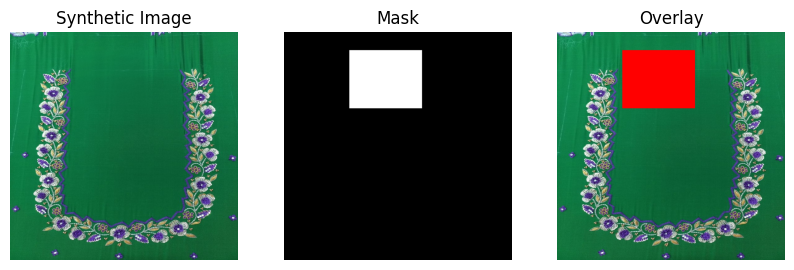

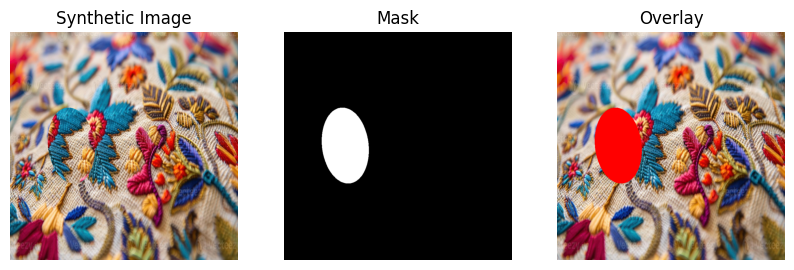

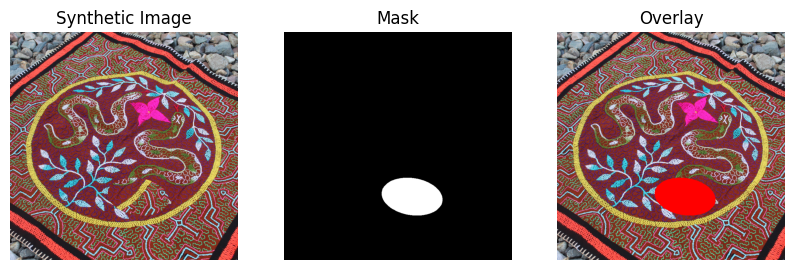

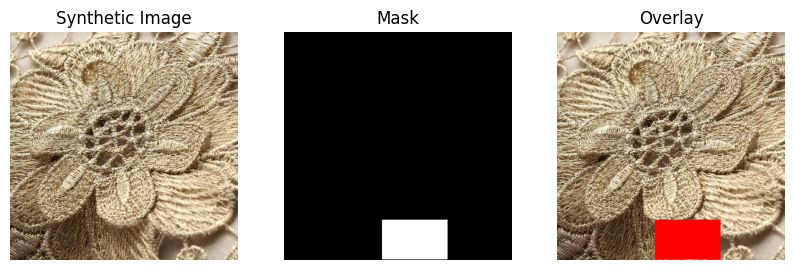

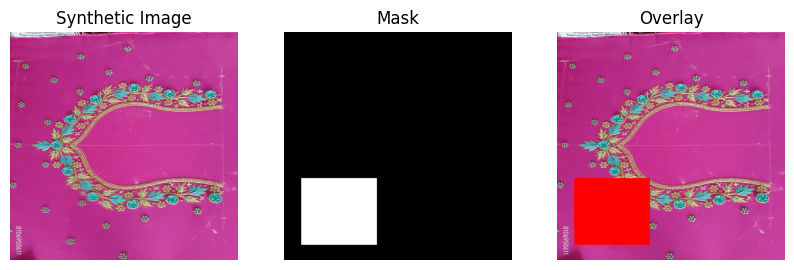

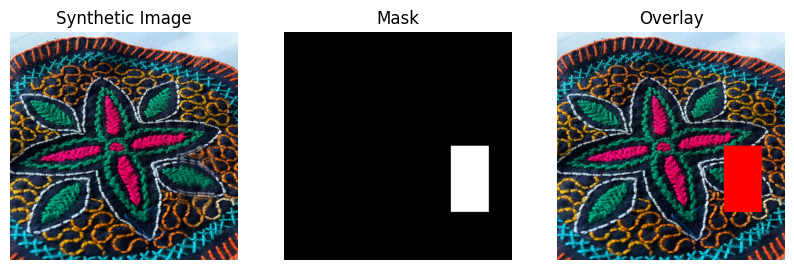

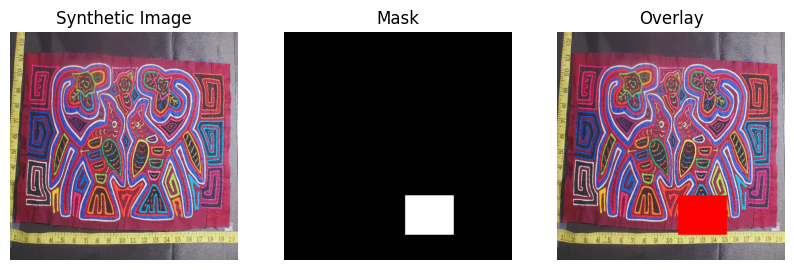

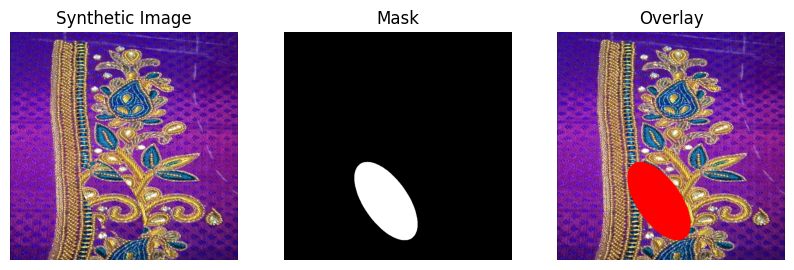

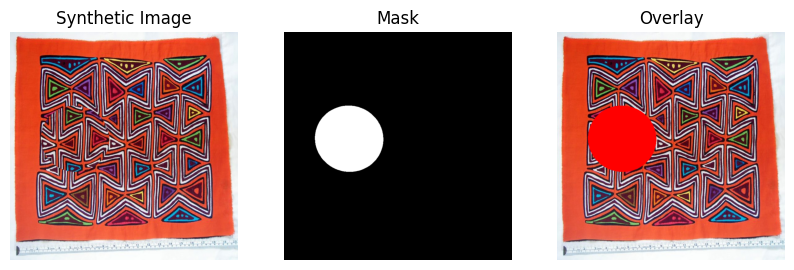

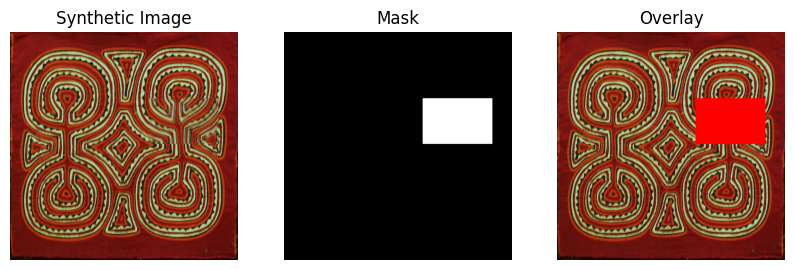

In [14]:
import cv2
import os
import random
import matplotlib.pyplot as plt

SYN_IMG_PATH = "/content/drive/MyDrive/embroidery_dataset/synthetic/images"
SYN_MASK_PATH = "/content/drive/MyDrive/embroidery_dataset/synthetic/masks"

samples = random.sample(os.listdir(SYN_IMG_PATH), 10)

for name in samples:
    img = cv2.imread(os.path.join(SYN_IMG_PATH, name))
    # Corrected line: Form the mask filename by replacing '.png' with '_mask.png'
    mask = cv2.imread(os.path.join(SYN_MASK_PATH, name.replace(".png", "_mask.png")), 0)

    # Check if mask was loaded successfully before proceeding
    if mask is None:
        print(f"Warning: Could not load mask for {name}. Skipping.")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.title("Synthetic Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay")
    overlay = img.copy()
    overlay[mask > 0] = [255, 0, 0]
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()


In [8]:
import shutil
import os

SYN_BASE = "/content/drive/MyDrive/embroidery_dataset/synthetic"

for folder in ["images", "masks"]:
    path = os.path.join(SYN_BASE, folder)
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f"Deleted {path}")

# Recreate empty folders
os.makedirs(os.path.join(SYN_BASE, "images"), exist_ok=True)
os.makedirs(os.path.join(SYN_BASE, "masks"), exist_ok=True)


Deleted /content/drive/MyDrive/embroidery_dataset/synthetic/images
Deleted /content/drive/MyDrive/embroidery_dataset/synthetic/masks
